# 01. PyTorch Workflow Fundamentals

This notebook walks through a typical end-to-end PyTorch workflow: preparing data, building a model, training it, evaluating predictions, and saving/loading the result. A simple linear regression problem is used throughout, since the known ground-truth parameters make it easy to check the model actually learns.

**Resources**
1. Notebook: https://www.learnpytorch.io/01_pytorch_workflow/
2. Video: https://www.youtube.com/watch?v=V_xro1bcAuA&t=5277s


## Setup & Environment Check

Import the required libraries and check which device (CPU or GPU/ROCm) is available, so later tensor operations can be placed on the right device.


In [52]:
# Capture the runtime details so we know which image-processing paths are available.
import platform
import torch
from torch import nn as nn
import warnings
import torch
import numpy as np
import matplotlib.pyplot as plt

# Silence warnings so the notebook output stays focused on the examples.
warnings.filterwarnings("ignore")

print(f"--- System Information ---")
print(f"Platform: {platform.platform()}")
print(f"Python:   {platform.python_version()}")
print(f"PyTorch:  {torch.__version__}")

print(f"\n--- GPU/ROCm Accelerators ---")
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Device Count:   {torch.cuda.device_count()}")
    print(f"Primary Device: {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda:0")
else:
    print("Optimization Note: No CUDA-capable GPU detected. Operations will run on CPU.")
    DEVICE = torch.device("cpu")


--- System Information ---
Platform: Windows-11-10.0.26200-SP0
Python:   3.12.13
PyTorch:  2.9.1+rocm7.2.1

--- GPU/ROCm Accelerators ---
CUDA Available: True
Device Count:   1
Primary Device: AMD Radeon RX 7900 XT


## Data (Prep and Loading)

Generate a synthetic dataset for **linear regression** with known parameters (`weight` and `bias`). Knowing the true values in advance makes it possible to check afterward how closely the trained model recovers them.


In [53]:
# Known parameters for the workflow.
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [54]:
len(X), len(y)

(50, 50)

### Train/Test Split

Split the data into a **training set** (used to fit the model) and a **test set** (held out to evaluate how well the model generalizes to unseen data). Here, 80% of the data is used for training and 20% for testing.


In [55]:
# Train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Visualize

Plot the training and test data to get a visual sense of the split before building the model. This same plotting function is reused later to overlay the model's predictions.


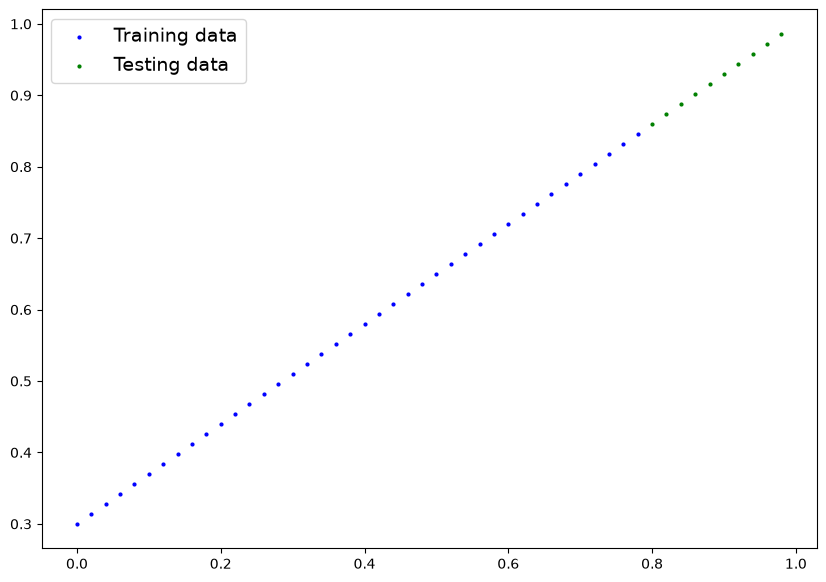

In [56]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot training data in blue, test data in green, and predictions in red.
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14})
    plt.show()

plot_predictions(X_train, y_train, X_test, y_test)

## Building a Model (Linear Regression)

**1. Model flow**
- The model starts with random values for its parameters.
- During training, those values are adjusted to better fit the true weight/bias.

**2. Main algorithms**
- **Gradient descent** — iteratively updates parameters in the direction that reduces the loss.
- **Backpropagation** — computes how much each parameter contributed to the loss, so gradient descent knows which direction to move.


In [57]:
# Linear regression model
class LinearRegressionModel(nn.Module): # nn.Module is the base class for all neural network modules in PyTorch
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # Start with a random weight and bias and adjust them during training to reach the optimal values.
                                                requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, # Start with a random weight and bias and adjust them during training to reach the optimal values.
                                             requires_grad=True, dtype=torch.float))

    # The forward method defines the computation performed at every call.
    def forward(self, x: torch.Tensor) -> torch.Tensor: # x is the input tensor, and the method returns the output tensor after applying the linear transformation.
        return self.weights * x + self.bias # linear formula

### PyTorch Model Building Essentials

- `nn.Module` — the base class for all neural network modules in PyTorch. Custom models subclass it and define their layers in `__init__` and their computation in `forward()`.
- `nn.Parameter` — wraps a tensor to mark it as a learnable parameter, so PyTorch's autograd tracks its gradients and the optimizer knows to update it.
- `model.parameters()` — returns an iterable of all learnable parameters in the model.
- `model.state_dict()` — returns a dictionary of the model's current parameter values, useful for inspecting, saving, and loading model state.


In [58]:
# Random seed
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [59]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making Predictions

Make predictions with the model using `torch.inference_mode()`, which disables gradient tracking during inference. This is not needed for prediction and skipping it saves memory and computation.


In [60]:
with torch.inference_mode(): # Faster than torch.no_grad() and more explicit about the intent to run inference.
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

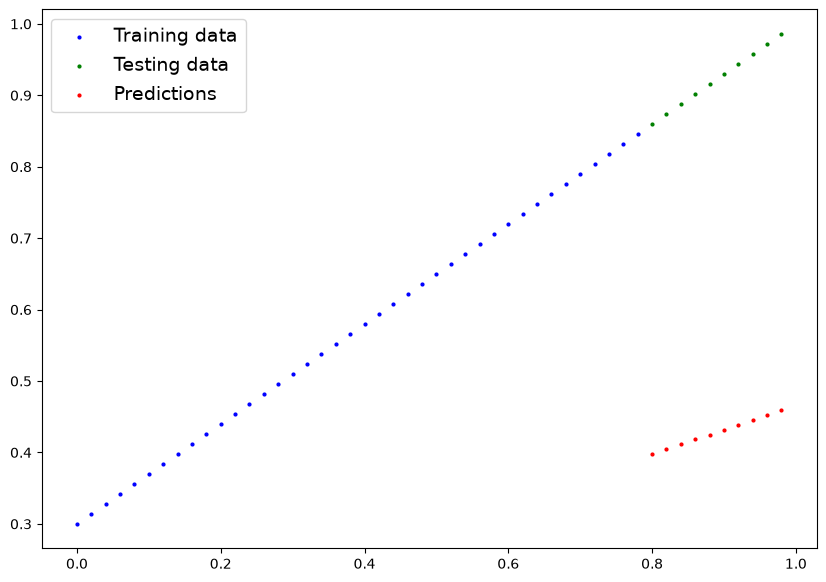

In [61]:
plot_predictions(X_train, y_train, X_test, y_test, y_preds)

### Training Model

Training a model in PyTorch follows a standard loop, repeated once per epoch:

1. **Forward pass** — run the input data through the model to get predictions.
2. **Calculate loss** — compare predictions to the true labels using a loss function.
3. **Zero gradients** — clear gradients from the previous step, since PyTorch accumulates them by default.
4. **Backward pass** — call `loss.backward()` to compute gradients of the loss with respect to each parameter.
5. **Update parameters** — call `optimizer.step()` to adjust parameters using those gradients.

The test set is evaluated the same way each epoch (without the gradient/optimizer steps), so training and test loss can be compared to check for overfitting.


In [62]:
# Loss function setup
loss_fn = nn.L1Loss() # Mean Absolute Error (MAE)

# Setup optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) # Stochastic Gradient Descent (SGD) optimizer

In [63]:
torch.manual_seed(42)
EPOCHS = 200

# Track the loss values for plotting later
epoch_count = []
train_loss_values = []
test_loss_values = []

for epoch in range(EPOCHS):
    model_0.train() # Set the model to training mode

    # 1. Forward pass: compute predicted y by passing X to the model
    y_pred = model_0(X_train)

    # 2. Compute and print loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero gradients, perform a backward pass, and update the weights.
    optimizer.zero_grad() 

    # 4. Backward pass: compute gradient of the loss with respect to model parameters
    loss.backward() 

    # 5. Update parameters based on gradients
    optimizer.step()

    # Testing
    model_0.eval() # Set the model to evaluation mode (turns off dropout and batch normalization layers, if any)

    with torch.inference_mode(): # Turns off gradient tracking (fastest)

        # 1. Forward pass: compute predicted y by passing X to the model
        test_pred = model_0(X_test)

        # 2. Compute and print test loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0 or epoch == EPOCHS : # Print every 10 epochs and the last epoch with the model's state dictionary and track loss values for plotting
        epoch_count.append(epoch)
        train_loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())
        print(f"Epoch {epoch} | Loss = {loss.item():.7f} | Test Loss = {test_loss.item():.7f}")
        print(model_0.state_dict())
    

Epoch 0 | Loss = 0.3128814 | Test Loss = 0.4810652
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch 10 | Loss = 0.1976713 | Test Loss = 0.3463552
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch 20 | Loss = 0.0890873 | Test Loss = 0.2172966
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch 30 | Loss = 0.0531485 | Test Loss = 0.1446402
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch 40 | Loss = 0.0454380 | Test Loss = 0.1136095
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch 50 | Loss = 0.0416786 | Test Loss = 0.0991995
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch 60 | Loss = 0.0381893 | Test Loss = 0.0888663
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch 70 | Loss = 0.0347609 | Test Loss = 0.0805938
OrderedDict({'weights': tensor([0.5288]), 'bias': tensor([0.3718])})
Epoch 80 | Loss = 0.0313238 | Tes

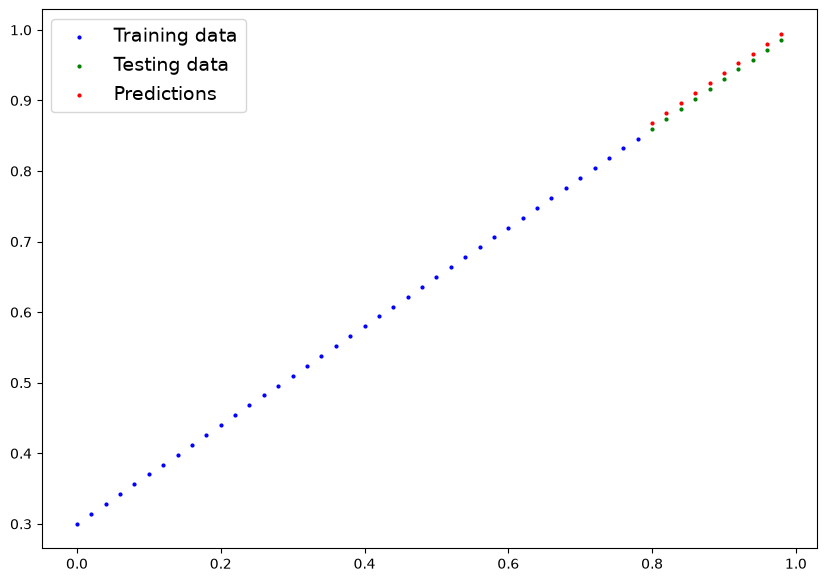

In [64]:
with torch.inference_mode():
    y_preds = model_0(X_test)

plot_predictions(X_train, y_train, X_test, y_test, y_preds)

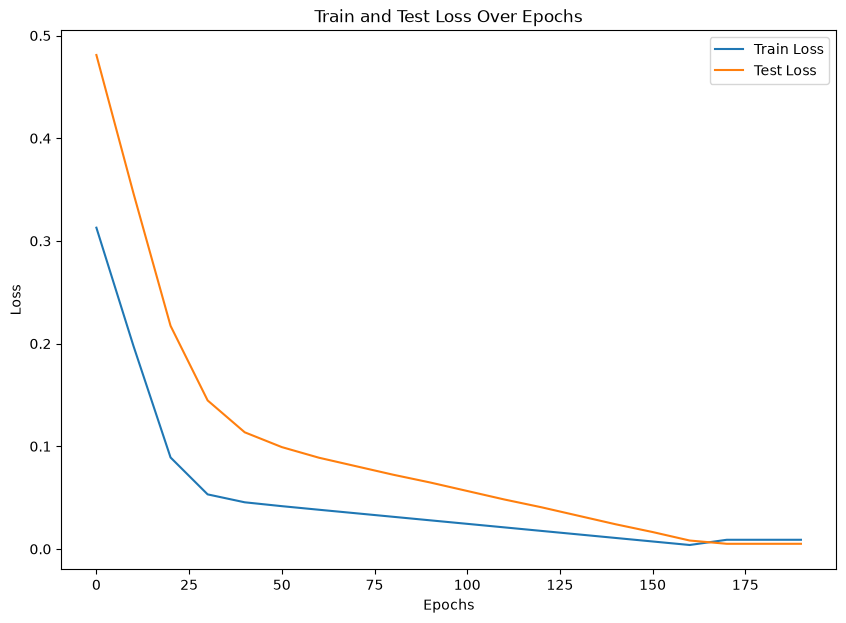

In [65]:
plt.figure(figsize=(10, 7))
plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Train and Test Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Saving a Model (3 Methods)

PyTorch offers a few ways to save a trained model, most commonly:

1. **`torch.save(model.state_dict(), path)`** — saves only the model's learned parameters (recommended approach). Requires re-creating the model class before loading the parameters back in with `model.load_state_dict(torch.load(path))`.
2. **`torch.save(model, path)`** — saves the entire model object, including its architecture. Simpler, but more fragile since it ties the saved file to the exact class definition and code structure used when saving.
3. **Checkpointing** — saving a dictionary that includes the model's `state_dict()` alongside extras like the optimizer state, epoch number, and loss, so training can be resumed later.

**Loading a model — `torch.load(path)`**

- Reads back whatever was saved at `path` (a `state_dict`, a full model, or a checkpoint dictionary).
- For the recommended `state_dict()` approach, `torch.load()` returns the parameter dictionary, which is then loaded into a freshly created instance of the model class with `model.load_state_dict(torch.load(path))`.
- By default, `torch.load()` restores tensors to the device they were saved from. If loading onto a different device (e.g. a checkpoint saved on GPU, loaded on CPU), pass `map_location` — e.g. `torch.load(path, map_location=torch.device("cpu"))`.

In [ ]:
# Save the model
from pathlib import Path

# Create a directory to save the model if it doesn't exist
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Create the model's pathing
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model's state dictionary (parameters) to the specified path
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

## Video Timestamp

Putting everything together — stopped at 07:44:28.
